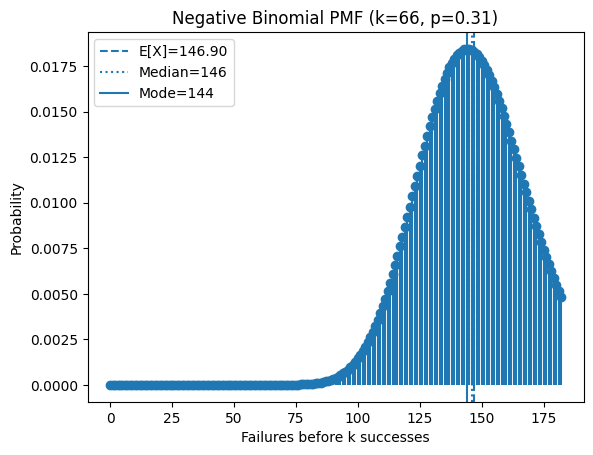

Expectation: 146.90322580645162
Median: 146
Mode: 144

First few rows of table:
   n           PMF           CDF
0  0  2.690740e-34  2.690740e-34
1  1  1.225363e-32  1.252271e-32
2  2  2.832427e-31  2.957654e-31
3  3  4.429916e-30  4.725681e-30
4  4  5.272707e-29  5.745275e-29


In [ ]:
import math
from math import comb, floor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


xi1 = 2      # 0=Bernoulli, 1=Poisson, 2=Negative Binomial, 3=Geometric
xi2 = 66     # k for NegBin, λ for Poisson, p for Bernoulli if ξ1=0
xi3 = 0.31   # p for NegBin or Geometric (if ξ1=2 or ξ1=3)


def bernoulli_case(p):
    p_for = p
    p_against = 1 - p_for
    df = pd.DataFrame({
        "Outcome": ["for", "against"],
        "Probability": [p_for, p_against]
    })
    fig, ax = plt.subplots()
    ax.bar(df["Outcome"], df["Probability"])
    ax.set_ylim(0, 1)
    ax.set_xlabel("Outcome")
    ax.set_ylabel("Probability")
    ax.set_title("Bernoulli Outcomes")
    plt.show()
    return df, p_for, 1 if p_for >= 0.5 else 0, None

def poisson_case(lam):
    def pmf(n): return math.exp(-lam) * lam**n / math.factorial(n)
    mode = math.floor(lam)
    rows = []
    n = 0
    while True:
        p = pmf(n)
        rows.append((n, p))
        if n >= mode and p < 0.005:
            break
        n += 1
    df = pd.DataFrame(rows, columns=["n", "PMF"])
    df["CDF"] = df["PMF"].cumsum()
    median = int(df.loc[df["CDF"] >= 0.5, "n"].iloc[0])
    fig, ax = plt.subplots()
    ax.stem(df["n"], df["PMF"], basefmt=" ")
    ax.axvline(lam, linestyle="--", label=f"E[X]={lam:.2f}")
    ax.axvline(median, linestyle=":", label=f"Median={median}")
    ax.axvline(mode, linestyle="-", label=f"Mode={mode}")
    ax.set_xlabel("n")
    ax.set_ylabel("Probability")
    ax.set_title(f"Poisson PMF (λ={lam})")
    ax.legend()
    plt.show()
    return df, lam, median, mode

def negbin_case(k, p):
    def pmf(n): return comb(n + k - 1, k - 1) * ((1 - p) ** n) * (p ** k)
    mode = int(floor((k - 1) * (1 - p) / p))
    rows = []
    n = 0
    while True:
        prob = pmf(n)
        rows.append((n, prob))
        if n >= mode and prob < 0.005:
            break
        n += 1
    df = pd.DataFrame(rows, columns=["n", "PMF"])
    df["CDF"] = df["PMF"].cumsum()
    exp_val = k * (1 - p) / p
    median = int(df.loc[df["CDF"] >= 0.5, "n"].iloc[0])
    fig, ax = plt.subplots()
    ax.stem(df["n"], df["PMF"], basefmt=" ")
    ax.axvline(exp_val, linestyle="--", label=f"E[X]={exp_val:.2f}")
    ax.axvline(median, linestyle=":", label=f"Median={median}")
    ax.axvline(mode, linestyle="-", label=f"Mode={mode}")
    ax.set_xlabel("Failures before k successes")
    ax.set_ylabel("Probability")
    ax.set_title(f"Negative Binomial PMF (k={k}, p={p})")
    ax.legend()
    plt.show()
    return df, exp_val, median, mode

def geometric_case(p):
    def pmf(n): return ((1 - p) ** (n - 1)) * p
    mode = 1
    rows = []
    n = 1
    while True:
        prob = pmf(n)
        rows.append((n, prob))
        if n >= mode and prob < 0.005:
            break
        n += 1
    df = pd.DataFrame(rows, columns=["n", "PMF"])
    df["CDF"] = df["PMF"].cumsum()
    exp_val = 1 / p
    median = int(df.loc[df["CDF"] >= 0.5, "n"].iloc[0])
    fig, ax = plt.subplots()
    ax.stem(df["n"], df["PMF"], basefmt=" ")
    ax.axvline(exp_val, linestyle="--", label=f"E[X]={exp_val:.2f}")
    ax.axvline(median, linestyle=":", label=f"Median={median}")
    ax.axvline(mode, linestyle="-", label=f"Mode={mode}")
    ax.set_xlabel("Trials until first success")
    ax.set_ylabel("Probability")
    ax.set_title(f"Geometric PMF (p={p})")
    ax.legend()
    plt.show()
    return df, exp_val, median, mode

# Choose the case
if xi1 == 0:
    table, exp_val, median, mode = bernoulli_case(xi2)
elif xi1 == 1:
    table, exp_val, median, mode = poisson_case(xi2)
elif xi1 == 2:
    table, exp_val, median, mode = negbin_case(xi2, xi3)
elif xi1 == 3:
    table, exp_val, median, mode = geometric_case(xi3)
else:
    raise ValueError("xi1 must be 0, 1, 2, or 3")

# Output results
print(f"Expectation: {exp_val}")
print(f"Median: {median}")
if mode is not None:
    print(f"Mode: {mode}")
print("\nFirst few rows of table:")
print(table.head())


# Task -1

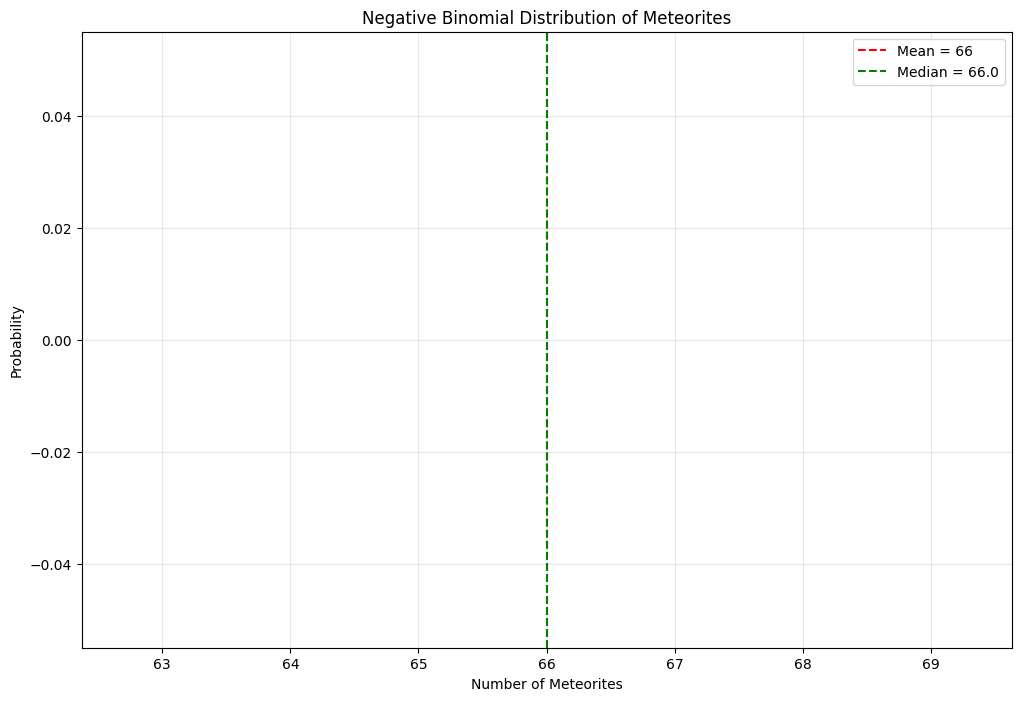

Expected value: 66
Median: 66.0
Variance: 215.40
Cutoff point (prob < 0.5%): 0
Probability at cutoff: 0.000000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parameters
r = 30  # number of successes
p = 0.31  # probability of success
expected_value = 66

# Generate negative binomial distribution
x_values = np.arange(0, 200)
pmf_values = stats.nbinom.pmf(x_values, r, p)

# Find where probability drops below 0.5%
cutoff_idx = np.where(pmf_values < 0.005)[0]
if len(cutoff_idx) > 0:
    cutoff = cutoff_idx[0]
else:
    cutoff = 200

# Calculate median
median = stats.nbinom.median(r, p)

# Plot
plt.figure(figsize=(12, 8))
plt.bar(x_values[:cutoff], pmf_values[:cutoff], alpha=0.7)
plt.axvline(expected_value, color='red', linestyle='--',
           label=f'Mean = {expected_value}')
plt.axvline(median, color='green', linestyle='--',
           label=f'Median = {median:.1f}')
plt.xlabel('Number of Meteorites')
plt.ylabel('Probability')
plt.title('Negative Binomial Distribution of Meteorites')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('task1_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Expected value: {expected_value}")
print(f"Median: {median}")
print(f"Variance: {stats.nbinom.var(r, p):.2f}")
print(f"Cutoff point (prob < 0.5%): {cutoff}")
print(f"Probability at cutoff: {pmf_values[cutoff]:.6f}")

# Task 2


/tmp/ipython-input-2407291914.py:11: RuntimeWarning: invalid value encountered in sqrt
  return xi5 * np.exp(-xi6 * np.sqrt(y)) + xi7 * np.exp(-xi8 * np.sqrt(y**3))
/tmp/ipython-input-2407291914.py:47: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(equation, mean_y)[0]


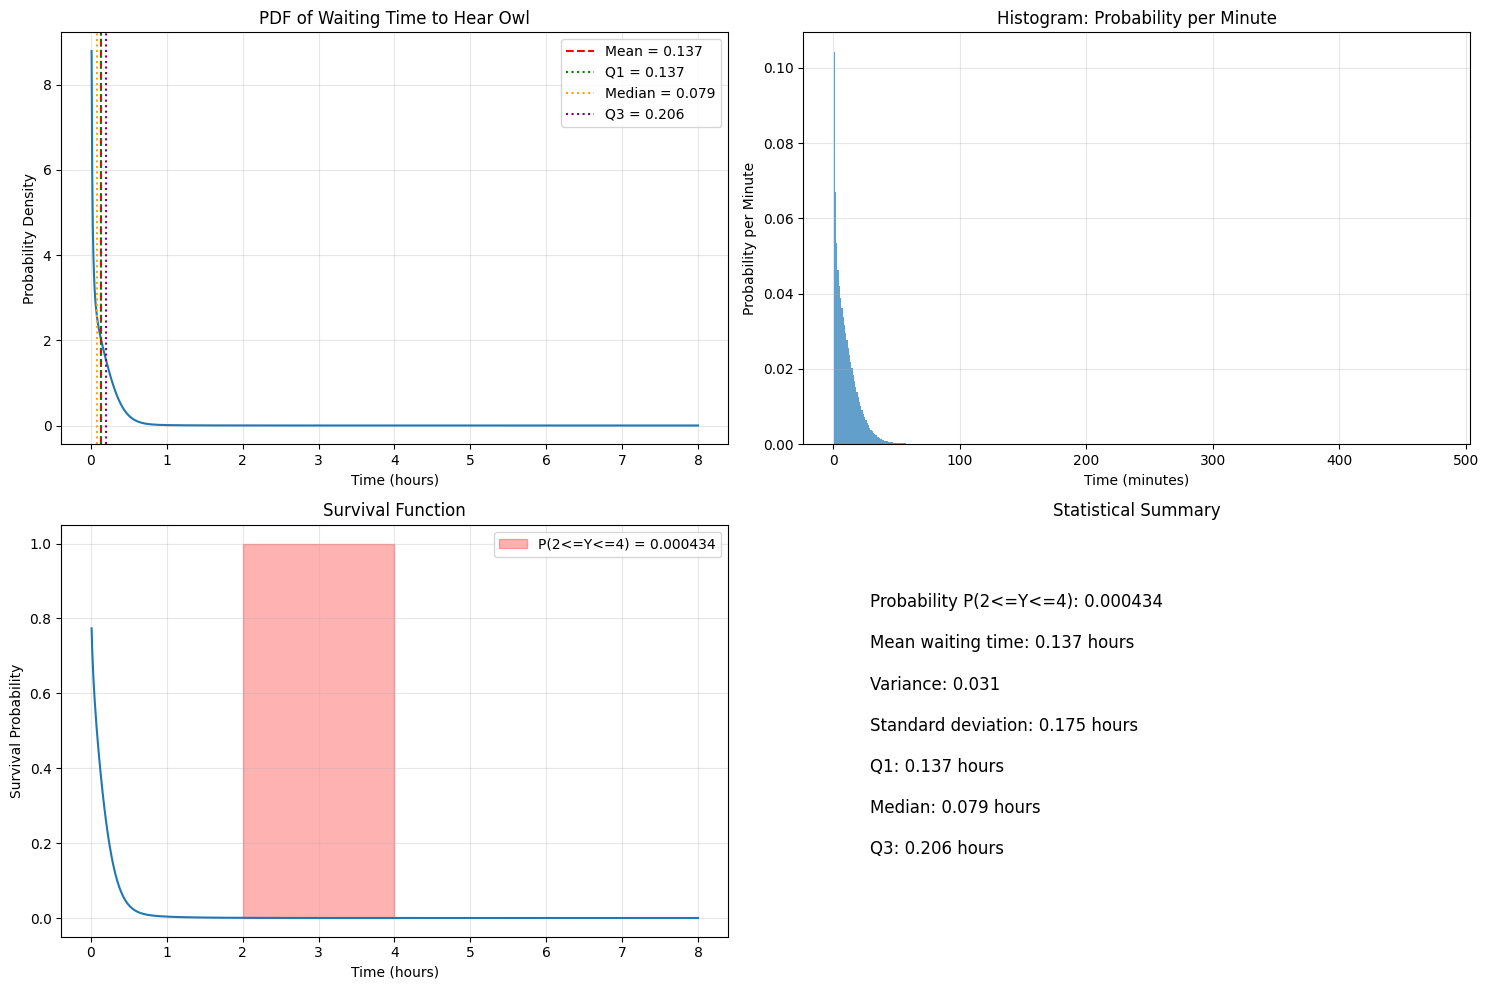

Probability of waiting between 2 and 4 hours: 0.000434
Mean waiting time: 0.137 hours
Variance: 0.031
Standard deviation: 0.175 hours
Q1: 0.137 hours
Median: 0.079 hours
Q3: 0.206 hours


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.optimize import fsolve

# Parameters
xi5, xi6, xi7, xi8 = 0.54, 5, 0.45, 9

# Define survival function
def survival_function(y):
    return xi5 * np.exp(-xi6 * np.sqrt(y)) + xi7 * np.exp(-xi8 * np.sqrt(y**3))

# Define PDF
def pdf(y):
    if y <= 0:
        return 0
    term1 = 1.35 * np.exp(-5 * np.sqrt(y)) / np.sqrt(y)
    term2 = 6.075 * y * np.exp(-9 * np.sqrt(y**3)) / np.sqrt(y)
    return term1 + term2

# Vectorize PDF for plotting
pdf_vec = np.vectorize(pdf)

# Time range
y_range = np.linspace(0.01, 8, 1000)
pdf_values = pdf_vec(y_range)
survival_values = survival_function(y_range)

# Calculate probability between 2 and 4 hours
prob_2_to_4 = survival_function(2) - survival_function(4)

# Calculate mean using numerical integration
mean_y = integrate.quad(survival_function, 0, np.inf)[0]

# Calculate variance
def second_moment_integrand(y):
    return 2 * y * survival_function(y)

second_moment = integrate.quad(second_moment_integrand, 0, np.inf)[0]
variance = second_moment - mean_y**2

# Calculate quartiles
def find_quantile(q):
    def equation(y):
        return 1 - survival_function(y) - q
    try:
        return fsolve(equation, mean_y)[0]
    except:
        return np.nan

q1 = find_quantile(0.25)
median = find_quantile(0.50)
q3 = find_quantile(0.75)

# Plotting PDF
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(y_range, pdf_values)
plt.axvline(mean_y, color='red', linestyle='--', label=f'Mean = {mean_y:.3f}')
plt.axvline(q1, color='green', linestyle=':', label=f'Q1 = {q1:.3f}')
plt.axvline(median, color='orange', linestyle=':', label=f'Median = {median:.3f}')
plt.axvline(q3, color='purple', linestyle=':', label=f'Q3 = {q3:.3f}')
plt.xlabel('Time (hours)')
plt.ylabel('Probability Density')
plt.title('PDF of Waiting Time to Hear Owl')
plt.legend()
plt.grid(True, alpha=0.3)

# Histogram by minutes
plt.subplot(2, 2, 2)
minutes = np.arange(1, 480)  # 8 hours in minutes
pdf_minutes = pdf_vec(minutes/60) / 60  # Convert to per-minute
plt.bar(minutes, pdf_minutes, width=1, alpha=0.7)
plt.xlabel('Time (minutes)')
plt.ylabel('Probability per Minute')
plt.title('Histogram: Probability per Minute')
plt.grid(True, alpha=0.3)

# Survival function
plt.subplot(2, 2, 3)
plt.plot(y_range, survival_values)
plt.fill_between([2, 4], [0, 0], [1, 1], alpha=0.3, color='red',
                label=f'P(2<=Y<=4) = {prob_2_to_4:.6f}')
plt.xlabel('Time (hours)')
plt.ylabel('Survival Probability')
plt.title('Survival Function')
plt.legend()
plt.grid(True, alpha=0.3)

# Summary plot
plt.subplot(2, 2, 4)
plt.text(0.1, 0.8, f'Probability P(2<=Y<=4): {prob_2_to_4:.6f}', fontsize=12)
plt.text(0.1, 0.7, f'Mean waiting time: {mean_y:.3f} hours', fontsize=12)
plt.text(0.1, 0.6, f'Variance: {variance:.3f}', fontsize=12)
plt.text(0.1, 0.5, f'Standard deviation: {np.sqrt(variance):.3f} hours', fontsize=12)
plt.text(0.1, 0.4, f'Q1: {q1:.3f} hours', fontsize=12)
plt.text(0.1, 0.3, f'Median: {median:.3f} hours', fontsize=12)
plt.text(0.1, 0.2, f'Q3: {q3:.3f} hours', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')
plt.title('Statistical Summary')

plt.tight_layout()
plt.savefig('task2_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Probability of waiting between 2 and 4 hours: {prob_2_to_4:.6f}")
print(f"Mean waiting time: {mean_y:.3f} hours")
print(f"Variance: {variance:.3f}")
print(f"Standard deviation: {np.sqrt(variance):.3f} hours")
print(f"Q1: {q1:.3f} hours")
print(f"Median: {median:.3f} hours")
print(f"Q3: {q3:.3f} hours")

# Task 3

Sample data: [ 72  62 231  23   7]
Sample size: 5
Sample mean: 79.0
MLE estimate of theta: 5.643
Expected bandwidth total for dual-router system: 79.0 TB


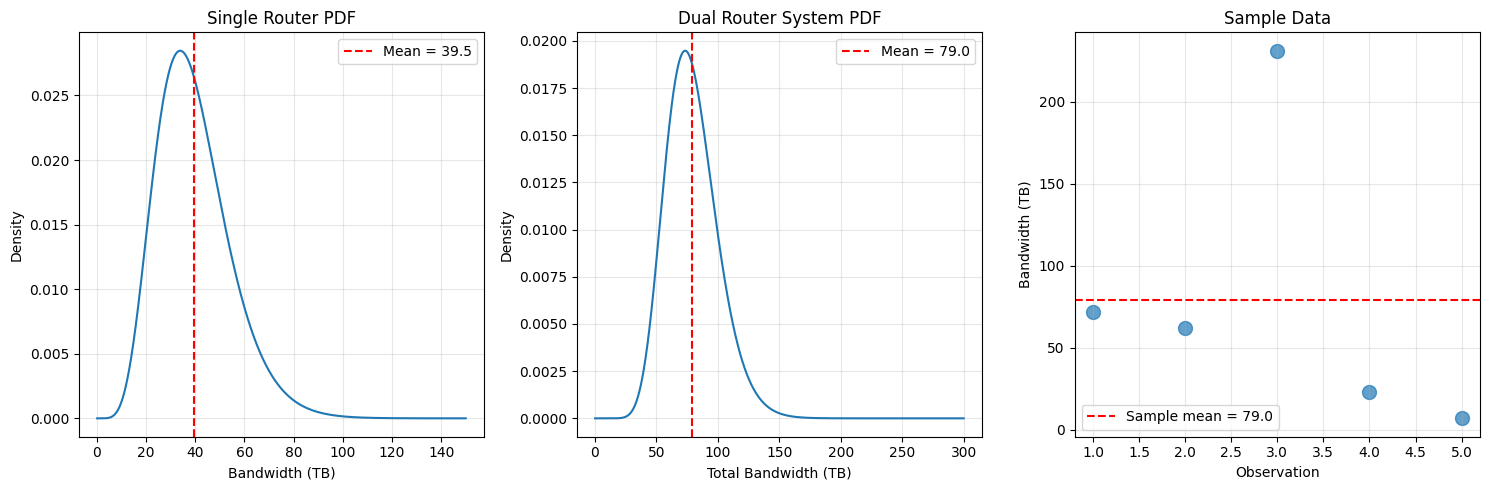

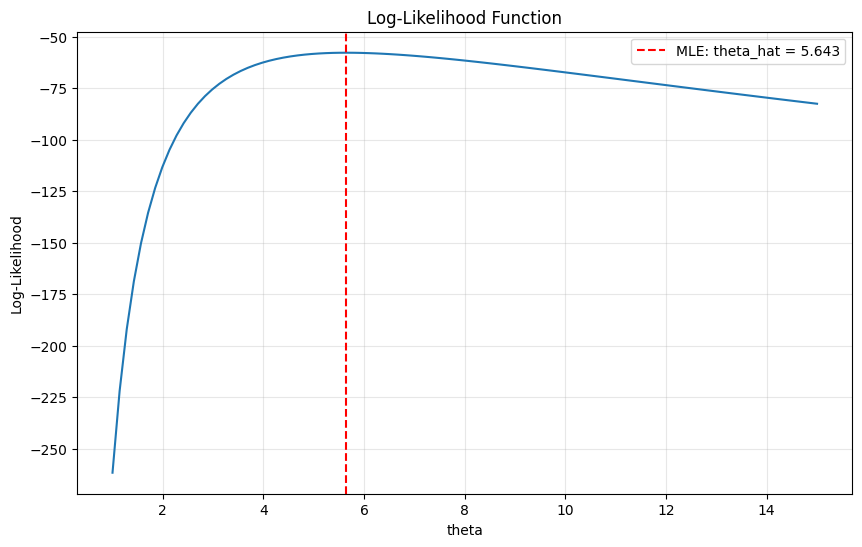

Log-likelihood at MLE: -57.83

Detailed Results:
Single router expected bandwidth: 39.5 TB
Dual router expected bandwidth: 79.0 TB
Single router variance: 222.9
Dual router variance: 445.8


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma

# Given data
data = np.array([72, 62, 231, 23, 7])
n = len(data)
sample_mean = np.mean(data)

print(f"Sample data: {data}")
print(f"Sample size: {n}")
print(f"Sample mean: {sample_mean}")

# MLE estimation
theta_hat = sample_mean / 14
print(f"MLE estimate of theta: {theta_hat:.3f}")

# Expected value of dual-router system
expected_T = 14 * theta_hat
print(f"Expected bandwidth total for dual-router system: {expected_T:.1f} TB")

# Define the PDF for single router (Gamma with α=7)
def single_router_pdf(s, theta):
    return (s**6 * np.exp(-s/theta)) / (gamma(7) * theta**7)

# Define the PDF for dual-router system (Gamma with α=14)
def dual_router_pdf(t, theta):
    return (t**13 * np.exp(-t/theta)) / (gamma(14) * theta**14)

# Plot both distributions
s_range = np.linspace(0.1, 150, 1000)
t_range = np.linspace(0.1, 300, 1000)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
single_pdf = single_router_pdf(s_range, theta_hat)
plt.plot(s_range, single_pdf)
plt.axvline(7 * theta_hat, color='red', linestyle='--',
           label=f'Mean = {7 * theta_hat:.1f}')
plt.xlabel('Bandwidth (TB)')
plt.ylabel('Density')
plt.title('Single Router PDF')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
dual_pdf = dual_router_pdf(t_range, theta_hat)
plt.plot(t_range, dual_pdf)
plt.axvline(expected_T, color='red', linestyle='--',
           label=f'Mean = {expected_T:.1f}')
plt.xlabel('Total Bandwidth (TB)')
plt.ylabel('Density')
plt.title('Dual Router System PDF')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(range(1, n+1), data, s=100, alpha=0.7)
plt.axhline(sample_mean, color='red', linestyle='--',
           label=f'Sample mean = {sample_mean:.1f}')
plt.xlabel('Observation')
plt.ylabel('Bandwidth (TB)')
plt.title('Sample Data')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task3_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Log-likelihood function
def log_likelihood(theta, data):
    n = len(data)
    ll = (-n * np.log(gamma(14)) - 14 * n * np.log(theta) +
          13 * np.sum(np.log(data)) - np.sum(data) / theta)
    return ll

# Plot log-likelihood
theta_range = np.linspace(1, 15, 100)
ll_values = [log_likelihood(theta, data) for theta in theta_range]

plt.figure(figsize=(10, 6))
plt.plot(theta_range, ll_values)
plt.axvline(theta_hat, color='red', linestyle='--',
           label=f'MLE: theta_hat = {theta_hat:.3f}')
plt.xlabel('theta')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('task3_likelihood.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Log-likelihood at MLE: {log_likelihood(theta_hat, data):.2f}")

# Additional analysis
print(f"\nDetailed Results:")
print(f"Single router expected bandwidth: {7 * theta_hat:.1f} TB")
print(f"Dual router expected bandwidth: {14 * theta_hat:.1f} TB")
print(f"Single router variance: {7 * theta_hat**2:.1f}")
print(f"Dual router variance: {14 * theta_hat**2:.1f}")

# Task 4

Sample data: [ 760  740  911  690 1018  835  697  810  692  720]
Sample size: 10
Sample mean: 787.3 g
Sample standard deviation: 108.28 g
Standard error: 34.24 g
Test statistic: -0.517
Critical value (alpha = 0.05): -1.833
P-value: 0.3088
Decision: Fail to reject H_0
Conclusion: Insufficient evidence that new system produces lower weights


/tmp/ipython-input-955653326.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([historical_sample, sample_data],


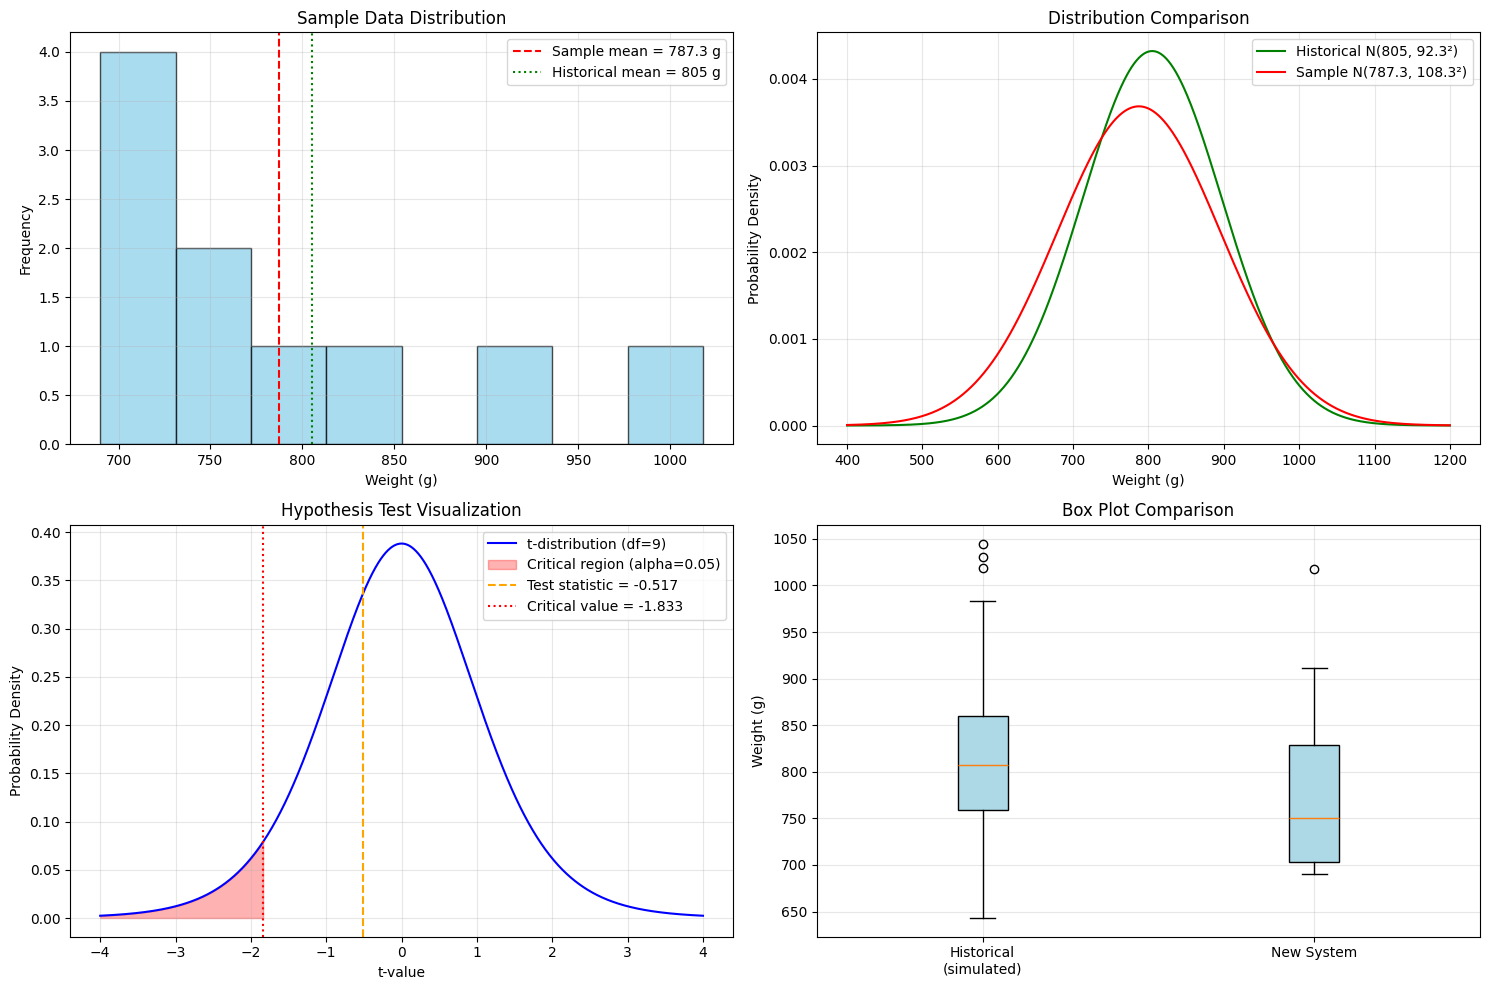

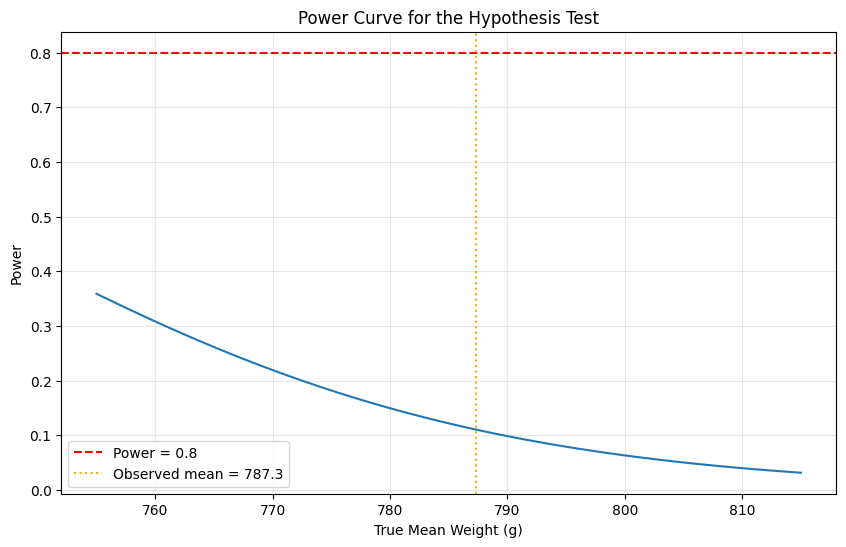


Summary:
H_0: mu = 805 g
H_1: mu < 805 g
Test statistic: t = -0.517
Critical value: t_critical = -1.833
P-value: 0.3088
Decision at alpha = 0.05: Fail to reject H_0
Conclusion: Insufficient evidence that new system produces lower weights

Manual calculations verification:
Sample variance: 11725.57
Sample std (manual): 108.28
SE (manual): 34.24
t-stat (manual): -0.517


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Given data
mu_0 = 805  # historical mean
sigma_0 = 92.3  # historical std dev
sample_data = np.array([760, 740, 911, 690, 1018, 835, 697, 810, 692, 720])
n = len(sample_data)
alpha = 0.05

# Sample statistics
sample_mean = np.mean(sample_data)
sample_std = np.std(sample_data, ddof=1)  # sample standard deviation
se = sample_std / np.sqrt(n)  # standard error

print(f"Sample data: {sample_data}")
print(f"Sample size: {n}")
print(f"Sample mean: {sample_mean:.1f} g")
print(f"Sample standard deviation: {sample_std:.2f} g")
print(f"Standard error: {se:.2f} g")

# Test statistic
t_stat = (sample_mean - mu_0) / se
print(f"Test statistic: {t_stat:.3f}")

# Critical value (left-tailed test)
df = n - 1
t_critical = stats.t.ppf(alpha, df)
print(f"Critical value (alpha = {alpha}): {t_critical:.3f}")

# P-value
p_value = stats.t.cdf(t_stat, df)
print(f"P-value: {p_value:.4f}")

# Decision
if t_stat <= t_critical:
    decision = "Reject H_0"
    conclusion = "Evidence that new system produces lower weights"
else:
    decision = "Fail to reject H_0"
    conclusion = "Insufficient evidence that new system produces lower weights"

print(f"Decision: {decision}")
print(f"Conclusion: {conclusion}")

# Visualization
plt.figure(figsize=(15, 10))

# Sample data histogram
plt.subplot(2, 2, 1)
plt.hist(sample_data, bins=8, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(sample_mean, color='red', linestyle='--',
           label=f'Sample mean = {sample_mean:.1f} g')
plt.axvline(mu_0, color='green', linestyle=':',
           label=f'Historical mean = {mu_0} g')
plt.xlabel('Weight (g)')
plt.ylabel('Frequency')
plt.title('Sample Data Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

# Normal distribution comparison
plt.subplot(2, 2, 2)
x_range = np.linspace(400, 1200, 1000)
historical_normal = stats.norm.pdf(x_range, mu_0, sigma_0)
sample_normal = stats.norm.pdf(x_range, sample_mean, sample_std)

plt.plot(x_range, historical_normal, label='Historical N(805, 92.3²)', color='green')
plt.plot(x_range, sample_normal, label=f'Sample N({sample_mean:.1f}, {sample_std:.1f}²)',
         color='red')
plt.xlabel('Weight (g)')
plt.ylabel('Probability Density')
plt.title('Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# T-distribution with critical region
plt.subplot(2, 2, 3)
t_range = np.linspace(-4, 4, 1000)
t_pdf = stats.t.pdf(t_range, df)

plt.plot(t_range, t_pdf, color='blue', label=f't-distribution (df={df})')
plt.fill_between(t_range[t_range <= t_critical], t_pdf[t_range <= t_critical],
                alpha=0.3, color='red', label=f'Critical region (alpha={alpha})')
plt.axvline(t_stat, color='orange', linestyle='--',
           label=f'Test statistic = {t_stat:.3f}')
plt.axvline(t_critical, color='red', linestyle=':',
           label=f'Critical value = {t_critical:.3f}')
plt.xlabel('t-value')
plt.ylabel('Probability Density')
plt.title('Hypothesis Test Visualization')
plt.legend()
plt.grid(True, alpha=0.3)

# Box plot comparison
plt.subplot(2, 2, 4)
historical_sample = np.random.normal(mu_0, sigma_0, 100)  # simulated for comparison
plt.boxplot([historical_sample, sample_data],
           labels=['Historical\n(simulated)', 'New System'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
plt.ylabel('Weight (g)')
plt.title('Box Plot Comparison')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task4_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Power analysis for different effect sizes
effect_sizes = np.linspace(-50, 10, 100)  # difference from mu_0
power_values = []

for effect in effect_sizes:
    mu_alt = mu_0 + effect
    # Power = P(reject H0 | H1 is true)
    # = P(t <= t_critical | mu = mu_alt)
    t_alt_dist_mean = (mu_alt - mu_0) / se
    power = stats.t.cdf(t_critical - t_alt_dist_mean, df)
    power_values.append(power)

plt.figure(figsize=(10, 6))
plt.plot(mu_0 + effect_sizes, power_values)
plt.axhline(0.8, color='red', linestyle='--', label='Power = 0.8')
plt.axvline(sample_mean, color='orange', linestyle=':',
           label=f'Observed mean = {sample_mean:.1f}')
plt.xlabel('True Mean Weight (g)')
plt.ylabel('Power')
plt.title('Power Curve for the Hypothesis Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('task4_power.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSummary:")
print(f"H_0: mu = {mu_0} g")
print(f"H_1: mu < {mu_0} g")
print(f"Test statistic: t = {t_stat:.3f}")
print(f"Critical value: t_critical = {t_critical:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Decision at alpha = {alpha}: {decision}")
print(f"Conclusion: {conclusion}")

# Additional calculations for manual verification
print(f"\nManual calculations verification:")
variance_sample = np.sum((sample_data - sample_mean)**2) / (n-1)
print(f"Sample variance: {variance_sample:.2f}")
print(f"Sample std (manual): {np.sqrt(variance_sample):.2f}")
print(f"SE (manual): {np.sqrt(variance_sample)/np.sqrt(n):.2f}")
print(f"t-stat (manual): {(sample_mean - mu_0)/(np.sqrt(variance_sample)/np.sqrt(n)):.3f}")

# Task 5

Data range: x in [-19, 20]
Data range: y in [-7.36e+13, -3.83e+00]
Design matrix shape: (22, 11)
Condition number: 7.28e+12
OLS MSE: 4.80e+21
OLS coefficient norm: 2.76e+10
Best lambda: 1.00e-10
Best Ridge MSE: 4.80e+21


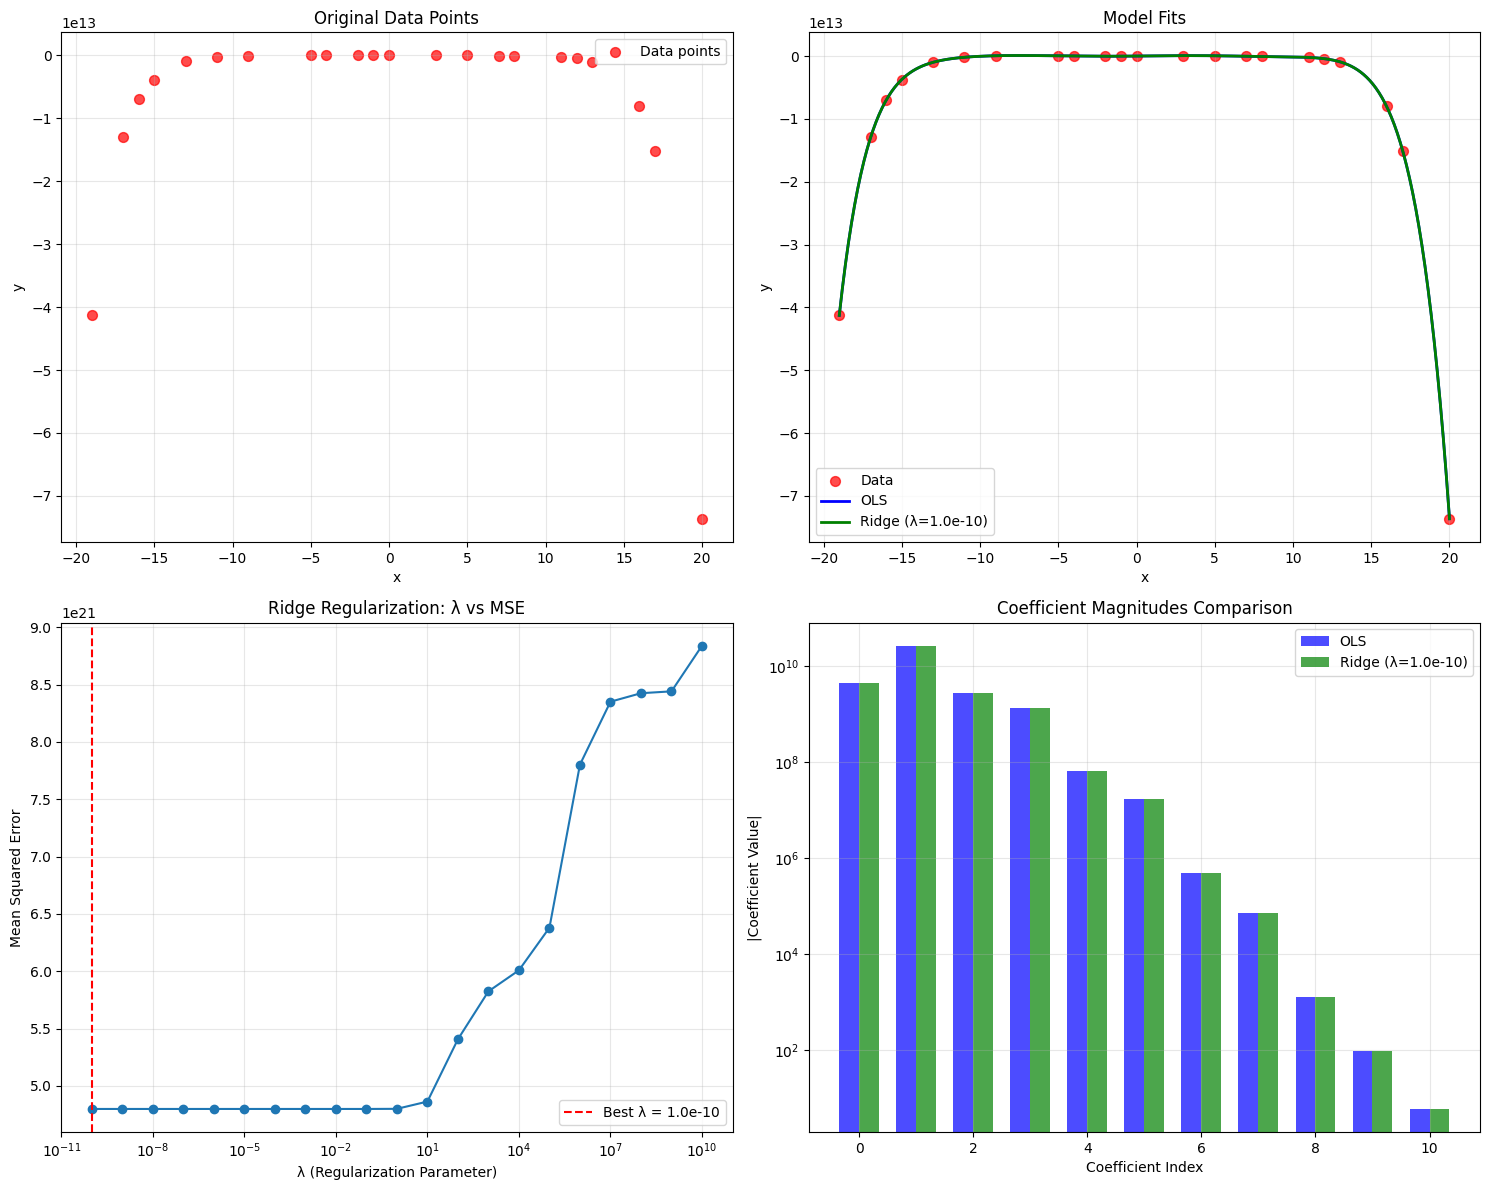


SUMMARY:
OLS Coefficients: [-4.42551091e+09  2.70697690e+10  2.84356470e+09 -1.38863825e+09
 -6.69361447e+07  1.70188805e+07  4.85249672e+05 -7.29998076e+04
 -1.28523569e+03  9.39401021e+01 -5.93465805e+00]
Ridge Coefficients: [-4.42645159e+09  2.70701586e+10  2.84364099e+09 -1.38864013e+09
 -6.69364971e+07  1.70188788e+07  4.85250907e+05 -7.29998039e+04
 -1.28523797e+03  9.39401021e+01 -5.93465539e+00]
OLS Coefficient L2 norm: 2.76e+10
Ridge Coefficient L2 norm: 2.76e+10
Regularization reduces coefficient magnitude by factor: 1.00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Data points
data_points = [
    (5, -79604356.07), (11, -196904195919.85), (-17, -12937324165399.09),
    (-16, -6972106715694.44), (-9, -21987176482.28), (0, -3.83),
    (-1, -14.43), (8, -8128637905.8), (3, -510861.14),
    (-13, -876670998861.45), (17, -15102310001490.28),
    (12, -474059412043.87), (-4, -5234398.13), (-11, -173447560826.22),
    (16, -7967591671270.98), (-2, -2724.75), (13, -989777520878.85),
    (-15, -3893899566908.56), (7, -2241783388.32), (-5, -55708584.61),
    (-19, -41285093599447.87), (20, -73638612459474.31)
]

# Extract x and y values
x_data = np.array([point[0] for point in data_points])
y_data = np.array([point[1] for point in data_points])

# Sort by x for plotting
sorted_indices = np.argsort(x_data)
x_sorted = x_data[sorted_indices]
y_sorted = y_data[sorted_indices]

print(f"Data range: x in [{x_data.min()}, {x_data.max()}]")
print(f"Data range: y in [{y_data.min():.2e}, {y_data.max():.2e}]")

# Create polynomial features (degree 10)
degree = 10
poly_features = PolynomialFeatures(degree=degree, include_bias=True)
X_poly = poly_features.fit_transform(x_data.reshape(-1, 1))

print(f"Design matrix shape: {X_poly.shape}")
print(f"Condition number: {np.linalg.cond(X_poly):.2e}")

# OLS Solution
ols_model = LinearRegression(fit_intercept=False)
ols_model.fit(X_poly, y_data)
ols_coeffs = ols_model.coef_
ols_predictions = ols_model.predict(X_poly)
ols_mse = np.mean((y_data - ols_predictions)**2)

print(f"OLS MSE: {ols_mse:.2e}")
print(f"OLS coefficient norm: {np.linalg.norm(ols_coeffs):.2e}")

# Ridge Regression with different lambda values
lambda_values = np.logspace(-10, 10, 21)
ridge_mses = []
ridge_norms = []

best_lambda = None
best_mse = float('inf')

for lam in lambda_values:
    ridge_model = Ridge(alpha=lam, fit_intercept=False)
    ridge_model.fit(X_poly, y_data)
    ridge_pred = ridge_model.predict(X_poly)
    mse = np.mean((y_data - ridge_pred)**2)
    coeff_norm = np.linalg.norm(ridge_model.coef_)

    ridge_mses.append(mse)
    ridge_norms.append(coeff_norm)

    if mse < best_mse:
        best_mse = mse
        best_lambda = lam

print(f"Best lambda: {best_lambda:.2e}")
print(f"Best Ridge MSE: {best_mse:.2e}")

# Final Ridge model with best lambda
ridge_final = Ridge(alpha=best_lambda, fit_intercept=False)
ridge_final.fit(X_poly, y_data)
ridge_coeffs = ridge_final.coef_
ridge_predictions = ridge_final.predict(X_poly)

# Plotting
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Original data
ax1.scatter(x_sorted, y_sorted, color='red', s=50, alpha=0.7, label='Data points')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Original Data Points')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Model predictions
x_plot = np.linspace(x_data.min(), x_data.max(), 200)
X_plot = poly_features.transform(x_plot.reshape(-1, 1))

try:
    ols_plot = ols_model.predict(X_plot)
    ridge_plot = ridge_final.predict(X_plot)

    ax2.scatter(x_sorted, y_sorted, color='red', s=50, alpha=0.7, label='Data')
    ax2.plot(x_plot, ols_plot, 'b-', label='OLS', linewidth=2)
    ax2.plot(x_plot, ridge_plot, 'g-', label=f'Ridge (λ={best_lambda:.1e})', linewidth=2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('Model Fits')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
except:
    ax2.text(0.5, 0.5, 'Numerical instability\nin predictions',
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Model Fits (Numerically Unstable)')

# Lambda vs MSE
ax3.semilogx(lambda_values, ridge_mses, 'o-')
ax3.axvline(best_lambda, color='red', linestyle='--', label=f'Best λ = {best_lambda:.1e}')
ax3.set_xlabel('λ (Regularization Parameter)')
ax3.set_ylabel('Mean Squared Error')
ax3.set_title('Ridge Regularization: λ vs MSE')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Coefficient comparison
coeff_indices = np.arange(len(ols_coeffs))
width = 0.35
ax4.bar(coeff_indices - width/2, np.abs(ols_coeffs), width,
        label='OLS', alpha=0.7, color='blue')
ax4.bar(coeff_indices + width/2, np.abs(ridge_coeffs), width,
        label=f'Ridge (λ={best_lambda:.1e})', alpha=0.7, color='green')
ax4.set_xlabel('Coefficient Index')
ax4.set_ylabel('|Coefficient Value|')
ax4.set_title('Coefficient Magnitudes Comparison')
ax4.set_yscale('log')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task5_regression.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary
print(f"\nSUMMARY:")
print(f"OLS Coefficients: {ols_coeffs}")
print(f"Ridge Coefficients: {ridge_coeffs}")
print(f"OLS Coefficient L2 norm: {np.linalg.norm(ols_coeffs):.2e}")
print(f"Ridge Coefficient L2 norm: {np.linalg.norm(ridge_coeffs):.2e}")
print(f"Regularization reduces coefficient magnitude by factor: "
      f"{np.linalg.norm(ols_coeffs)/np.linalg.norm(ridge_coeffs):.2f}")

# Task 6

Sample size: 10
Sample mean: 81.51
Sum of observations: 815.1
Prior parameters: alpha = 77, beta = 42

Posterior Gamma parameters:
Alpha (shape): 107
Beta (rate): 815.123810

(b) Bayes estimate (square-error loss): 0.131268
(c) Bayes estimate (mode): 0.130042

Posterior statistics:
Mean: 0.131268
Mode: 0.130042
Variance: 0.00016104
Standard deviation: 0.012690
95% Credible interval: [0.107578, 0.157282]


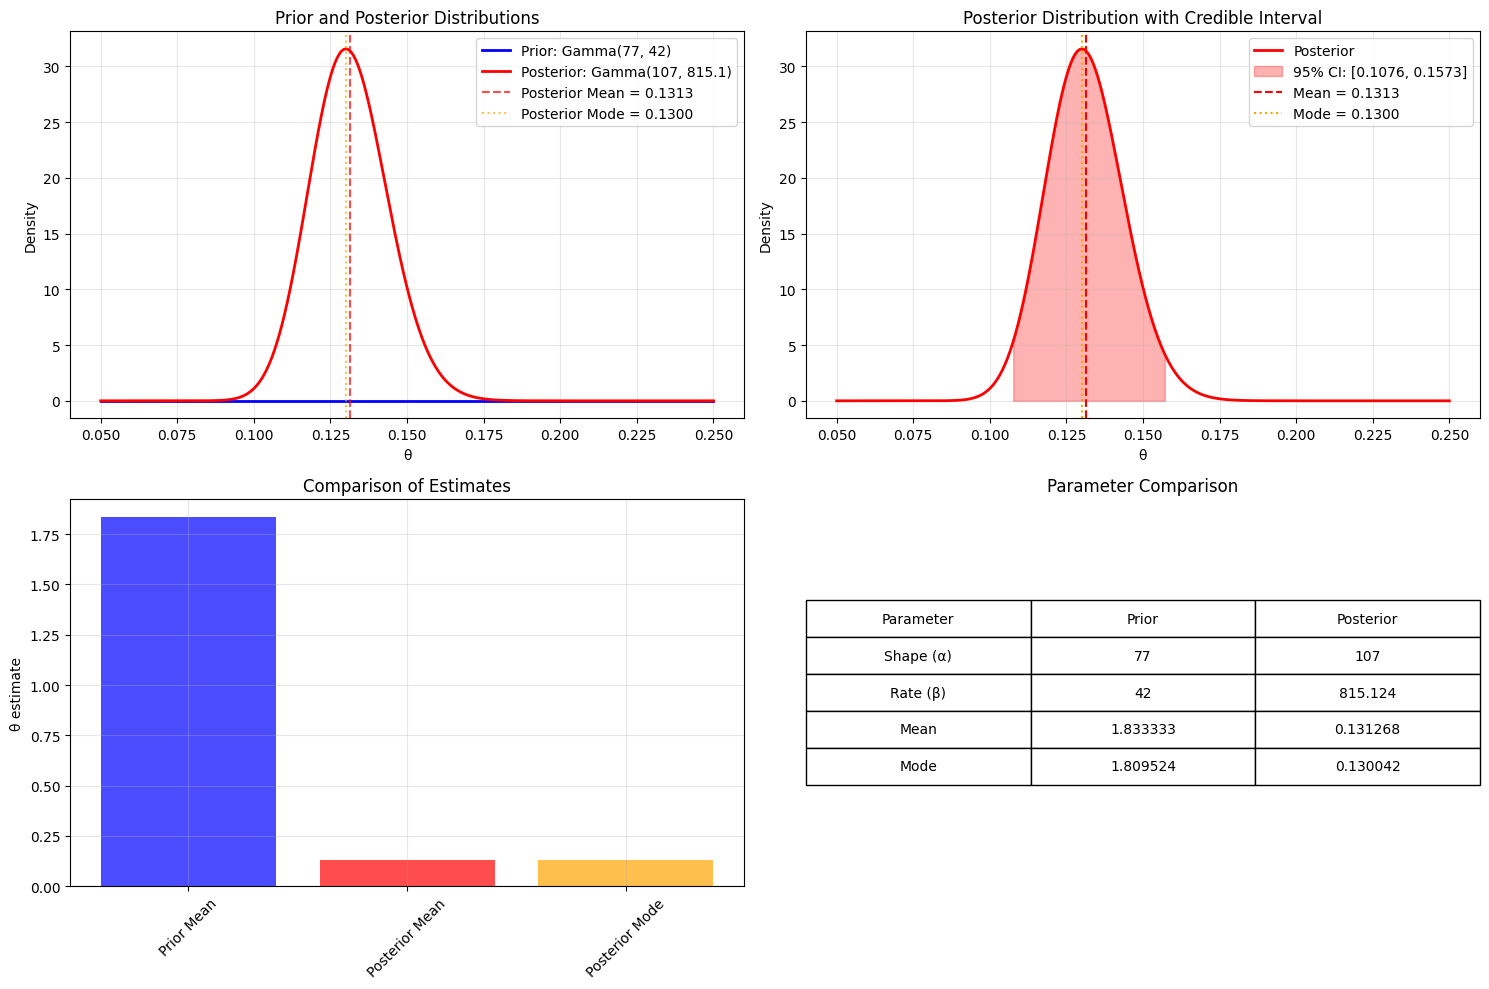


Verification:
Prior mean: 1.833333
Posterior mean: 0.131268
Update factor: 0.0716


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma as gamma_func

# Given parameters
n = 10  # sample size
alpha_likelihood = 3  # shape parameter of data distribution
prior_alpha = 77  # xi_17
prior_beta = 42   # xi_18
sample_mean = 81.51  # xi_19

# Calculate sum of observations
sum_x = n * sample_mean

print(f"Sample size: {n}")
print(f"Sample mean: {sample_mean}")
print(f"Sum of observations: {sum_x}")
print(f"Prior parameters: alpha = {prior_alpha}, beta = {prior_beta}")

# Posterior parameters for theta (using conjugate prior approach)
# For Gamma likelihood with Inverse-Gamma prior on precision tau = 1/theta
posterior_alpha = prior_alpha + n * alpha_likelihood
posterior_beta = sum_x + 1/prior_beta

print(f"\nPosterior Gamma parameters:")
print(f"Alpha (shape): {posterior_alpha}")
print(f"Beta (rate): {posterior_beta:.6f}")

# Bayesian estimates
# (b) Square-error loss (posterior mean)
bayes_mean = posterior_alpha / posterior_beta
print(f"\n(b) Bayes estimate (square-error loss): {bayes_mean:.6f}")

# (c) Mode of posterior
bayes_mode = (posterior_alpha - 1) / posterior_beta
print(f"(c) Bayes estimate (mode): {bayes_mode:.6f}")

# Additional statistics
posterior_var = posterior_alpha / (posterior_beta**2)
posterior_std = np.sqrt(posterior_var)

print(f"\nPosterior statistics:")
print(f"Mean: {bayes_mean:.6f}")
print(f"Mode: {bayes_mode:.6f}")
print(f"Variance: {posterior_var:.8f}")
print(f"Standard deviation: {posterior_std:.6f}")

# Credible intervals
alpha_ci = 0.05  # 95% credible interval
ci_lower = stats.gamma.ppf(alpha_ci/2, posterior_alpha, scale=1/posterior_beta)
ci_upper = stats.gamma.ppf(1-alpha_ci/2, posterior_alpha, scale=1/posterior_beta)

print(f"95% Credible interval: [{ci_lower:.6f}, {ci_upper:.6f}]")

# Plotting
theta_range = np.linspace(0.05, 0.25, 1000)

# Prior distribution
prior_pdf = stats.gamma.pdf(theta_range, prior_alpha, scale=1/prior_beta)

# Posterior distribution
posterior_pdf = stats.gamma.pdf(theta_range, posterior_alpha, scale=1/posterior_beta)

plt.figure(figsize=(15, 10))

# Prior vs Posterior
plt.subplot(2, 2, 1)
plt.plot(theta_range, prior_pdf, 'b-', linewidth=2, label=f'Prior: Gamma({prior_alpha}, {prior_beta})')
plt.plot(theta_range, posterior_pdf, 'r-', linewidth=2,
         label=f'Posterior: Gamma({posterior_alpha}, {posterior_beta:.1f})')
plt.axvline(bayes_mean, color='red', linestyle='--', alpha=0.7, label=f'Posterior Mean = {bayes_mean:.4f}')
plt.axvline(bayes_mode, color='orange', linestyle=':', alpha=0.7, label=f'Posterior Mode = {bayes_mode:.4f}')
plt.xlabel('θ')
plt.ylabel('Density')
plt.title('Prior and Posterior Distributions')
plt.legend()
plt.grid(True, alpha=0.3)

# Posterior with credible interval
plt.subplot(2, 2, 2)
plt.plot(theta_range, posterior_pdf, 'r-', linewidth=2, label='Posterior')
plt.fill_between(theta_range[(theta_range >= ci_lower) & (theta_range <= ci_upper)],
                posterior_pdf[(theta_range >= ci_lower) & (theta_range <= ci_upper)],
                alpha=0.3, color='red', label=f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
plt.axvline(bayes_mean, color='red', linestyle='--', label=f'Mean = {bayes_mean:.4f}')
plt.axvline(bayes_mode, color='orange', linestyle=':', label=f'Mode = {bayes_mode:.4f}')
plt.xlabel('θ')
plt.ylabel('Density')
plt.title('Posterior Distribution with Credible Interval')
plt.legend()
plt.grid(True, alpha=0.3)

# Summary statistics visualization
plt.subplot(2, 2, 3)
estimates = ['Prior Mean', 'Posterior Mean', 'Posterior Mode']
values = [prior_alpha/prior_beta, bayes_mean, bayes_mode]
colors = ['blue', 'red', 'orange']

plt.bar(estimates, values, color=colors, alpha=0.7)
plt.ylabel('θ estimate')
plt.title('Comparison of Estimates')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Prior vs Posterior comparison table
plt.subplot(2, 2, 4)
table_data = [
    ['Parameter', 'Prior', 'Posterior'],
    ['Shape (α)', f'{prior_alpha}', f'{posterior_alpha}'],
    ['Rate (β)', f'{prior_beta}', f'{posterior_beta:.3f}'],
    ['Mean', f'{prior_alpha/prior_beta:.6f}', f'{bayes_mean:.6f}'],
    ['Mode', f'{(prior_alpha-1)/prior_beta:.6f}', f'{bayes_mode:.6f}']
]

plt.axis('tight')
plt.axis('off')
table = plt.table(cellText=table_data[1:], colLabels=table_data[0],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
plt.title('Parameter Comparison')

plt.tight_layout()
plt.savefig('task6_bayesian.png', dpi=300, bbox_inches='tight')
plt.show()

# Verification using numerical integration
print(f"\nVerification:")
print(f"Prior mean: {prior_alpha/prior_beta:.6f}")
print(f"Posterior mean: {posterior_alpha/posterior_beta:.6f}")
print(f"Update factor: {(posterior_alpha/posterior_beta)/(prior_alpha/prior_beta):.4f}")